# Challenge 1

In [ ]:
# 1. Download 20 random stocks
# 2. Calculate risk and reward potential
# 3. Compare the covariance and correlation
# 4. Find the best 5 to invest in long term

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Download 20 random stocks

In [4]:
tickers = [
    'DIS', 'SMCI', 'BA', 'PLTR', 'CRWD', 
    'CVNA', 'INTC', 'PLUG', 'AMC', 'PTON', 
    'DJT', 'GME', 'TSLA', 'MSTR', 'TGT', 
    'NVDA', 'FISV', 'TTD', 'LULU', 'META'
]

In [5]:
stocks = yf.download(tickers, start = "2022-01-01", end = "2025-12-19", auto_adjust = False)

[*********************100%***********************]  20 of 20 completed


In [6]:
stocks

Price        Adj Close                                                  \
Ticker             AMC          BA        CRWD        CVNA         DIS   
Date                                                                     
2022-01-03  265.200012  207.860001  198.330002  239.630005  153.153305   
2022-01-04  254.899994  213.630005  189.190002  220.940002  152.147018   
2022-01-05  227.500000  213.070007  179.289993  198.000000  151.619446   
2022-01-06  224.600006  211.339996  187.490005  191.380005  153.290100   
2022-01-07  229.899994  215.500000  188.990005  184.710007  154.198700   
...                ...         ...         ...         ...         ...   
2025-12-12    2.120000  204.380005  504.779999  455.679993  110.849998   
2025-12-15    1.970000  205.500000  487.470001  447.920013  110.489998   
2025-12-16    1.930000  206.710007  488.529999  455.179993  111.620003   
2025-12-17    1.820000  206.330002  470.019989  446.230011  110.629997   
2025-12-18    1.780000  208.270004  477.260010  465.739990  111.870003   

Price                                                                ...  \
Ticker            DJT        FISV        GME       INTC        LULU  ...   
Date                                                                 ...   
2022-01-03  51.700001  107.620003  38.209999  49.350479  387.559998  ...   
2022-01-04  52.230000  109.000000  37.227501  49.285561  380.820007  ...   
2022-01-05  50.369999  108.360001  32.342499  49.962608  362.480011  ...   
2022-01-06  60.270000  109.139999  32.757500  50.092457  368.769989  ...   
2022-01-07  53.980000  108.830002  35.154999  49.563797  355.209991  ...   
...               ...         ...        ...        ...         ...  ...   
2025-12-12  10.650000   68.750000  21.230000  37.810001  204.970001  ...   
2025-12-15  10.460000   68.970001  22.090000  37.509998  206.289993  ...   
2025-12-16  10.730000   67.699997  22.280001  37.310001  206.740005  ...   
2025-12-17  10.470000   68.330002  23.030001  36.049999  207.869995  ...   
2025-12-18  14.860000   68.000000  22.559999  36.279999  215.110001  ...   

Price         Volume                                                      \
Ticker          META      MSTR       NVDA      PLTR       PLUG      PTON   
Date                                                                       
2022-01-03  14537900   3458000  391547000  34283600   13410100  12761400   
2022-01-04  15998000   3947000  527154000  39643200   15773000  21842300   
2022-01-05  20564500   5470000  498064000  58445900   19086800  15467400   
2022-01-06  27962800   4845000  454186000  49737100   21825300  18061300   
2022-01-07  14722000   4258000  409939000  37989300   13168900  17078400   
...              ...       ...        ...       ...        ...       ...   
2025-12-12  14016900  14532100  204274900  42427400  114453400   8653300   
2025-12-15  15549100  25393400  164775600  32796100   94449200   9517800   
2025-12-16  14309100  21181000  148588100  42070300   97117800   7540500   
2025-12-17  15598500  19144900  222775500  50424700   81987500   7057400   
2025-12-18  19733100  17467900  175570000  39974500  122218400   5054300   

Price                                               
Ticker          SMCI      TGT       TSLA       TTD  
Date                                                
2022-01-03   2522000  3018000  103931400   3735200  
2022-01-04   3054000  3327600  100248300   7467000  
2022-01-05   2963000  3885800   80119800   6571000  
2022-01-06   1548000  4193200   90336600   5358300  
2022-01-07   1360000  3052900   84164700   6380000  
...              ...      ...        ...       ...  
2025-12-12  22435100  5260200   95656700  13651000  
2025-12-15  18470600  5730100  114542200  17389400  
2025-12-16  20835800  5142500  107608100  13116400  
2025-12-17  24797200  6830400  106490400  14206300  
2025-12-18  25524200  9592900   94870000  10649400  

[995 rows x 120 columns]

In [7]:
stocks.to_csv("stocks_challenge1.csv")

In [15]:
stocks = pd.read_csv("stocks_challenge1.csv", header = [0,1], index_col = [0], parse_dates = [0])

In [17]:
stocks

Price        Adj Close                                                  \
Ticker             AMC          BA        CRWD        CVNA         DIS   
Date                                                                     
2022-01-03  265.200012  207.860001  198.330002  239.630005  153.153305   
2022-01-04  254.899994  213.630005  189.190002  220.940002  152.147018   
2022-01-05  227.500000  213.070007  179.289993  198.000000  151.619446   
2022-01-06  224.600006  211.339996  187.490005  191.380005  153.290100   
2022-01-07  229.899994  215.500000  188.990005  184.710007  154.198700   
...                ...         ...         ...         ...         ...   
2025-12-12    2.120000  204.380005  504.779999  455.679993  110.849998   
2025-12-15    1.970000  205.500000  487.470001  447.920013  110.489998   
2025-12-16    1.930000  206.710007  488.529999  455.179993  111.620003   
2025-12-17    1.820000  206.330002  470.019989  446.230011  110.629997   
2025-12-18    1.780000  208.270004  477.260010  465.739990  111.870003   

Price                                                                ...  \
Ticker            DJT        FISV        GME       INTC        LULU  ...   
Date                                                                 ...   
2022-01-03  51.700001  107.620003  38.209999  49.350479  387.559998  ...   
2022-01-04  52.230000  109.000000  37.227501  49.285561  380.820007  ...   
2022-01-05  50.369999  108.360001  32.342499  49.962608  362.480011  ...   
2022-01-06  60.270000  109.139999  32.757500  50.092457  368.769989  ...   
2022-01-07  53.980000  108.830002  35.154999  49.563797  355.209991  ...   
...               ...         ...        ...        ...         ...  ...   
2025-12-12  10.650000   68.750000  21.230000  37.810001  204.970001  ...   
2025-12-15  10.460000   68.970001  22.090000  37.509998  206.289993  ...   
2025-12-16  10.730000   67.699997  22.280001  37.310001  206.740005  ...   
2025-12-17  10.470000   68.330002  23.030001  36.049999  207.869995  ...   
2025-12-18  14.860000   68.000000  22.559999  36.279999  215.110001  ...   

Price         Volume                                                      \
Ticker          META      MSTR       NVDA      PLTR       PLUG      PTON   
Date                                                                       
2022-01-03  14537900   3458000  391547000  34283600   13410100  12761400   
2022-01-04  15998000   3947000  527154000  39643200   15773000  21842300   
2022-01-05  20564500   5470000  498064000  58445900   19086800  15467400   
2022-01-06  27962800   4845000  454186000  49737100   21825300  18061300   
2022-01-07  14722000   4258000  409939000  37989300   13168900  17078400   
...              ...       ...        ...       ...        ...       ...   
2025-12-12  14016900  14532100  204274900  42427400  114453400   8653300   
2025-12-15  15549100  25393400  164775600  32796100   94449200   9517800   
2025-12-16  14309100  21181000  148588100  42070300   97117800   7540500   
2025-12-17  15598500  19144900  222775500  50424700   81987500   7057400   
2025-12-18  19733100  17467900  175570000  39974500  122218400   5054300   

Price                                               
Ticker          SMCI      TGT       TSLA       TTD  
Date                                                
2022-01-03   2522000  3018000  103931400   3735200  
2022-01-04   3054000  3327600  100248300   7467000  
2022-01-05   2963000  3885800   80119800   6571000  
2022-01-06   1548000  4193200   90336600   5358300  
2022-01-07   1360000  3052900   84164700   6380000  
...              ...      ...        ...       ...  
2025-12-12  22435100  5260200   95656700  13651000  
2025-12-15  18470600  5730100  114542200  17389400  
2025-12-16  20835800  5142500  107608100  13116400  
2025-12-17  24797200  6830400  106490400  14206300  
2025-12-18  25524200  9592900   94870000  10649400  

[995 rows x 120 columns]

In [18]:
stocks.describe()

Price    Adj Close                                                  \
Ticker         AMC          BA        CRWD        CVNA         DIS   
count   995.000000  995.000000  995.000000  995.000000  995.000000   
mean     44.052844  188.405970  269.970643  129.261588  102.761355   
std      61.144251   28.881920  124.550953  120.065005   15.161203   
min       1.780000  115.860001   94.720001    3.720000   77.495041   
25%       3.465000  169.279999  161.800003   30.125000   91.213619   
50%       6.160000  188.619995  244.360001   83.760002  100.144638   
75%      58.950001  210.049995  364.564987  212.269997  111.417290   
max     294.399994  264.269989  557.530029  472.730011  154.257324   

Price                                                               ...  \
Ticker         DJT        FISV         GME        INTC        LULU  ...   
count   995.000000  994.000000  995.000000  995.000000  995.000000  ...   
mean     27.582558  135.853602   23.618847   31.618608  324.797638  ...   
std      16.669762   39.896129    6.357352    8.458490   75.739521  ...   
min      10.290000   59.770000   10.010000   18.129999  159.869995  ...   
25%      16.134999  104.415001   20.190001   24.240000  283.714996  ...   
50%      20.940001  125.199997   23.219999   30.693058  320.380005  ...   
75%      34.580000  158.615005   27.100000   37.532270  376.474991  ...   
max      97.540001  237.789993   48.750000   51.854645  511.290009  ...   

Price         Volume                                                          \
Ticker          META          MSTR          NVDA          PLTR          PLUG   
count   9.950000e+02  9.950000e+02  9.950000e+02  9.950000e+02  9.950000e+02   
mean    2.255594e+07  1.225879e+07  4.058194e+08  6.018470e+07  4.597966e+07   
std     1.714931e+07  9.227753e+06  1.841919e+08  4.008898e+07  4.685768e+07   
min     4.726100e+06  2.184000e+06  1.051570e+08  1.082440e+07  6.271700e+06   
25%     1.274900e+07  6.297500e+06  2.495558e+08  3.469665e+07  1.910740e+07   
50%     1.858640e+07  9.741400e+06  3.981633e+08  4.829700e+07  2.960250e+07   
75%     2.652955e+07  1.558710e+07  5.161995e+08  7.226920e+07  5.328615e+07   
max     2.323166e+08  1.004440e+08  1.543911e+09  4.502905e+08  4.995021e+08   

Price                                                                         
Ticker          PTON          SMCI           TGT          TSLA           TTD  
count   9.950000e+02  9.950000e+02  9.950000e+02  9.950000e+02  9.950000e+02  
mean    1.432323e+07  3.997113e+07  5.266722e+06  1.044816e+08  6.573158e+06  
std     1.385929e+07  4.403035e+07  4.311229e+06  3.857883e+07  7.435926e+06  
min     2.915800e+06  1.073000e+06  1.495200e+06  3.625290e+07  1.168300e+06  
25%     8.801400e+06  1.031650e+07  3.115500e+06  7.670465e+07  3.207800e+06  
50%     1.123860e+07  2.779700e+07  4.133200e+06  9.722460e+07  4.548200e+06  
75%     1.520555e+07  5.023910e+07  6.049450e+06  1.229184e+08  7.313450e+06  
max     2.465291e+08  3.697350e+08  6.455770e+07  3.065906e+08  1.115068e+08  

[8 rows x 120 columns]

In [19]:
close = stocks.loc[:,"Close"]

In [20]:
close

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Date,,,,,,,,,,,,,,,,,,,,
2022-01-03,265.200012,207.860001,198.330002,239.630005,156.759995,51.700001,107.620003,38.209999,53.209999,387.559998,338.540009,55.826000,30.121000,18.530001,28.790001,35.200001,4.562000,231.949997,399.926666,90.110001
2022-01-04,254.899994,213.630005,189.190002,220.940002,155.729996,52.230000,109.000000,37.227501,53.139999,380.820007,336.529999,55.106998,29.290001,18.170000,28.150000,33.820000,4.714000,234.169998,383.196655,85.360001
2022-01-05,227.500000,213.070007,179.289993,198.000000,155.190002,50.369999,108.360001,32.342499,53.869999,362.480011,324.170013,50.910000,27.604000,16.959999,26.270000,32.230000,4.536000,228.860001,362.706665,79.639999
2022-01-06,224.600006,211.339996,187.490005,191.380005,156.899994,60.270000,109.139999,32.757500,54.009998,368.769989,332.459991,49.862000,28.177999,16.740000,25.219999,33.860001,4.510000,231.350006,354.899994,76.930000
2022-01-07,229.899994,215.500000,188.990005,184.710007,157.830002,53.980000,108.830002,35.154999,53.439999,355.209991,331.790009,48.294998,27.247000,16.559999,24.959999,35.580002,4.408000,230.779999,342.320007,78.940002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12,2.120000,204.380005,504.779999,455.679993,111.599998,10.650000,68.750000,21.230000,37.810001,204.970001,644.229980,176.449997,175.020004,183.570007,2.320000,6.540000,32.330002,97.089996,458.959991,36.650002
2025-12-15,1.970000,205.500000,487.470001,447.920013,110.489998,10.460000,68.970001,22.090000,37.509998,206.289993,647.510010,162.080002,176.289993,183.250000,2.220000,6.250000,31.370001,97.559998,475.309998,36.189999
2025-12-16,1.930000,206.710007,488.529999,455.179993,111.620003,10.730000,67.699997,22.280001,37.310001,206.740005,657.150024,167.500000,177.720001,187.750000,2.290000,6.190000,31.660000,97.669998,489.880005,36.639999


## 2. Calculate Risk and Return

In [21]:
#normalise data

In [24]:
normclose = close.div(close.iloc[0]).mul(100)

In [25]:
normclose

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Date,,,,,,,,,,,,,,,,,,,,
2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2022-01-04,96.116132,102.775909,95.391520,92.200475,99.342945,101.025143,101.282287,97.428688,99.868446,98.260917,99.406271,98.712066,97.241130,98.057201,97.777001,96.079543,103.331881,100.957103,95.816730,94.728665
2022-01-05,85.784310,102.506498,90.399834,82.627382,98.998474,97.427463,100.687603,84.644071,101.240368,93.528747,95.755304,91.194067,91.643703,91.527245,91.246959,91.562497,99.430074,98.667818,90.693293,88.380867
2022-01-06,84.690798,101.674202,94.534364,79.864792,100.089308,116.576401,101.412374,85.730177,101.503475,95.151716,98.204048,89.316805,93.549348,90.339985,87.599856,96.193181,98.860158,99.741328,88.741268,85.373432
2022-01-07,86.689285,103.675551,95.290679,77.081335,100.682577,104.410056,101.124325,92.004710,100.432249,91.652904,98.006144,86.509866,90.458482,89.368585,86.696764,101.079548,96.624292,99.495582,85.595694,87.604042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12,0.799397,98.325798,254.515199,190.159823,71.191632,20.599612,63.882176,55.561372,71.058076,52.887296,190.296557,316.071358,581.056414,990.663791,8.058353,18.579545,708.680475,41.858158,114.761038,40.672513
2025-12-15,0.742836,98.864620,245.787323,186.921506,70.483543,20.232108,64.086601,57.812093,70.494266,53.227886,191.265432,290.330672,585.272705,988.936823,7.711011,17.755681,687.637050,42.060788,118.849289,40.162022
2025-12-16,0.727753,99.446746,246.321784,189.951168,71.204393,20.754351,62.906519,58.309346,70.118403,53.344000,194.112958,300.039407,590.020250,1013.221765,7.954150,17.585227,693.993890,42.108213,122.492458,40.661413


<function matplotlib.pyplot.show(close=None, block=None)>

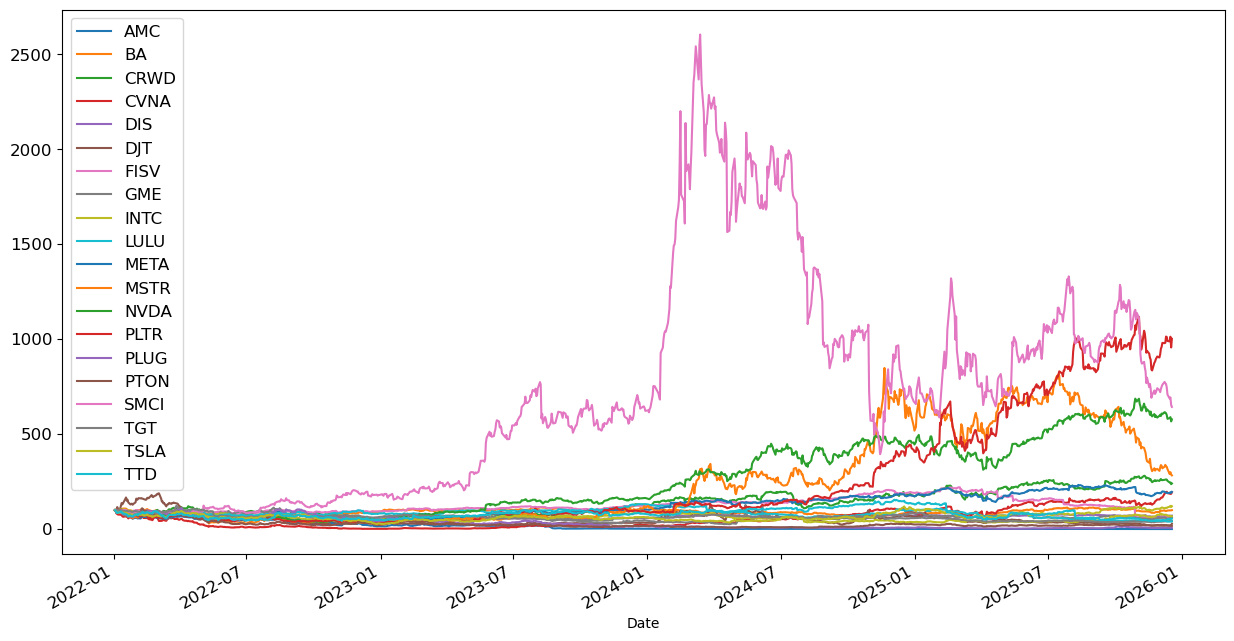

In [26]:
normclose.plot(figsize = (15,8), fontsize = 12)
plt.legend(fontsize = 12)
plt.show

In [27]:
ret = close.pct_change().dropna()
ret.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_6008\1974114209.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = close.pct_change().dropna()


Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Date,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.038839,0.027759,-0.046085,-0.077995,-0.006571,0.010251,0.012823,-0.025713,-0.001316,-0.017391,-0.005937,-0.012879,-0.027589,-0.019428,-0.022230,-0.039205,0.033319,0.009571,-0.041833,-0.052713
2022-01-05,-0.107493,-0.002621,-0.052328,-0.103829,-0.003467,-0.035612,-0.005872,-0.131220,0.013737,-0.048159,-0.036728,-0.076161,-0.057562,-0.066593,-0.066785,-0.047014,-0.037760,-0.022676,-0.053471,-0.067010
2022-01-06,-0.012747,-0.008119,0.045736,-0.033434,0.011019,0.196546,0.007198,0.012831,0.002599,0.017353,0.025573,-0.020585,0.020794,-0.012972,-0.039970,0.050574,-0.005732,0.010880,-0.021523,-0.034028
2022-01-07,0.023597,0.019684,0.008000,-0.034852,0.005927,-0.104364,-0.002840,0.073189,-0.010554,-0.036771,-0.002015,-0.031427,-0.033040,-0.010753,-0.010309,0.050797,-0.022616,-0.002464,-0.035447,0.026128
2022-01-10,-0.009134,-0.028724,0.018572,-0.006876,-0.007793,0.035754,-0.009924,-0.067345,0.033121,-0.019087,-0.011212,-0.002071,0.005615,-0.003623,-0.008413,-0.034008,0.002269,-0.014559,0.030342,0.026096


In [28]:
ret.describe()

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
count,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000
mean,-0.002892,0.000277,0.001404,0.003535,-0.000158,0.001031,-0.000151,0.001379,0.000100,-0.000212,0.001112,0.002792,0.002340,0.003240,-0.000687,-0.000186,0.003428,-0.000566,0.000950,0.000039
std,0.066141,0.023455,0.032239,0.076971,0.019054,0.071599,0.022901,0.064362,0.031154,0.027364,0.029253,0.059106,0.034046,0.043340,0.061753,0.056156,0.056250,0.023694,0.039074,0.042618
min,-0.419534,-0.104710,-0.147464,-0.429210,-0.131632,-0.281768,-0.440438,-0.393770,-0.260585,-0.198047,-0.263901,-0.255540,-0.169682,-0.213080,-0.404722,-0.242806,-0.326751,-0.249303,-0.154262,-0.386052
25%,-0.028812,-0.010780,-0.016111,-0.031906,-0.009262,-0.025958,-0.008219,-0.025470,-0.016627,-0.012283,-0.011730,-0.032482,-0.017492,-0.019113,-0.038010,-0.034727,-0.023624,-0.011511,-0.020509,-0.019004
50%,-0.004783,0.000447,0.002135,0.000850,-0.000245,-0.004446,0.001027,-0.002164,-0.000514,0.000632,0.000815,-0.001379,0.002990,0.001377,-0.008507,-0.003041,0.001064,-0.000459,0.001037,0.000429
75%,0.020964,0.012642,0.018722,0.030394,0.009472,0.020791,0.009000,0.020495,0.015249,0.013094,0.013960,0.034057,0.021395,0.023617,0.029164,0.029741,0.028575,0.010778,0.022194,0.018254
max,0.783505,0.153741,0.162965,0.560206,0.118943,0.883624,0.083459,0.743986,0.227711,0.158899,0.232824,0.257303,0.243696,0.308014,0.346290,0.354167,0.359363,0.177543,0.226900,0.362202


In [29]:
summary = ret.describe().T.loc[:,["mean","std"]]
summary

,mean,std
Ticker,,
AMC,-0.002892,0.066141
BA,0.000277,0.023455
CRWD,0.001404,0.032239
CVNA,0.003535,0.076971
DIS,-0.000158,0.019054
DJT,0.001031,0.071599
FISV,-0.000151,0.022901
GME,0.001379,0.064362
INTC,0.000100,0.031154


In [30]:
summary["mean"] = summary["mean"] * 252
summary["std"] = summary["std"] * np.sqrt(252)
summary 

,mean,std
Ticker,,
AMC,-0.728771,1.049963
BA,0.069871,0.372334
CRWD,0.353733,0.511776
CVNA,0.890703,1.221883
DIS,-0.039698,0.302472
DJT,0.259834,1.136599
FISV,-0.038145,0.363540
GME,0.347415,1.021708
INTC,0.025171,0.494562


<function matplotlib.pyplot.show(close=None, block=None)>

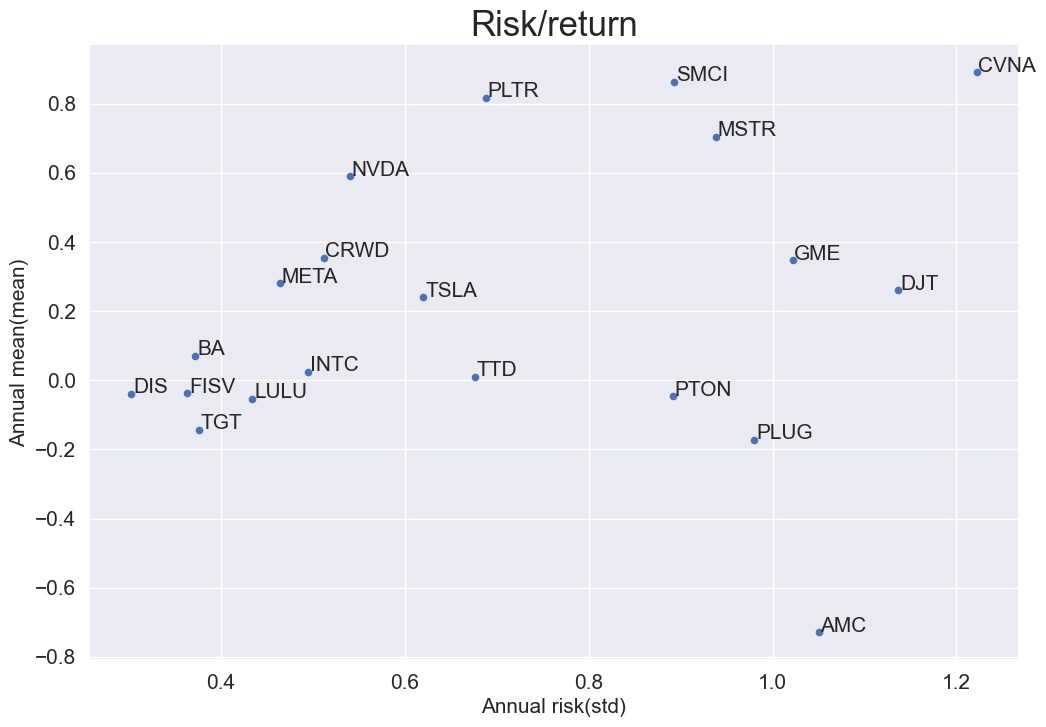

In [32]:
import seaborn as sns
sns.set()
summary.plot.scatter(x = "std", y = "mean", figsize = (12,8), fontsize = 15)
for i in summary.index:
    plt.annotate(i,xy = (summary.loc[i,"std"]+0.002, summary.loc[i, "mean"]+0.002),size =15)
plt.xlabel("Annual risk(std)",fontsize = 15)
plt.ylabel("Annual mean(mean)",fontsize = 15)
plt.title("Risk/return",fontsize = 25)
plt.show

## Correlation and Covariance

In [33]:
ret

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Date,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.038839,0.027759,-0.046085,-0.077995,-0.006571,0.010251,0.012823,-0.025713,-0.001316,-0.017391,-0.005937,-0.012879,-0.027589,-0.019428,-0.022230,-0.039205,0.033319,0.009571,-0.041833,-0.052713
2022-01-05,-0.107493,-0.002621,-0.052328,-0.103829,-0.003467,-0.035612,-0.005872,-0.131220,0.013737,-0.048159,-0.036728,-0.076161,-0.057562,-0.066593,-0.066785,-0.047014,-0.037760,-0.022676,-0.053471,-0.067010
2022-01-06,-0.012747,-0.008119,0.045736,-0.033434,0.011019,0.196546,0.007198,0.012831,0.002599,0.017353,0.025573,-0.020585,0.020794,-0.012972,-0.039970,0.050574,-0.005732,0.010880,-0.021523,-0.034028
2022-01-07,0.023597,0.019684,0.008000,-0.034852,0.005927,-0.104364,-0.002840,0.073189,-0.010554,-0.036771,-0.002015,-0.031427,-0.033040,-0.010753,-0.010309,0.050797,-0.022616,-0.002464,-0.035447,0.026128
2022-01-10,-0.009134,-0.028724,0.018572,-0.006876,-0.007793,0.035754,-0.009924,-0.067345,0.033121,-0.019087,-0.011212,-0.002071,0.005615,-0.003623,-0.008413,-0.034008,0.002269,-0.014559,0.030342,0.026096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12,-0.018519,0.018285,-0.024862,-0.036067,0.001256,-0.023831,0.008656,-0.028820,-0.043027,0.096038,-0.012992,-0.037370,-0.032665,-0.021169,-0.016949,-0.036819,-0.049677,0.001237,0.027009,-0.009995
2025-12-15,-0.070755,0.005480,-0.034292,-0.017029,-0.009946,-0.017840,0.003200,0.040509,-0.007934,0.006440,0.005091,-0.081439,0.007256,-0.001743,-0.043103,-0.044343,-0.029694,0.004841,0.035624,-0.012551
2025-12-16,-0.020305,0.005888,0.002174,0.016208,0.010227,0.025813,-0.018414,0.008601,-0.005332,0.002181,0.014888,0.033440,0.008112,0.024557,0.031532,-0.009600,0.009244,0.001128,0.030654,0.012434


In [34]:
ret.cov()

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Ticker,,,,,,,,,,,,,,,,,,,,
AMC,0.004375,0.000343,0.000505,0.001425,0.000311,0.000284,0.000150,0.002474,0.000285,0.000343,0.000324,0.000969,0.000472,0.000771,0.001120,0.001021,0.000345,0.000237,0.000657,0.000740
BA,0.000343,0.000550,0.000235,0.000547,0.000177,0.000198,0.000137,0.000296,0.000252,0.000220,0.000228,0.000473,0.000295,0.000346,0.000438,0.000390,0.000286,0.000161,0.000323,0.000349
CRWD,0.000505,0.000235,0.001039,0.001051,0.000232,0.000310,0.000169,0.000515,0.000356,0.000313,0.000397,0.000783,0.000580,0.000748,0.000566,0.000581,0.000552,0.000183,0.000545,0.000616
CVNA,0.001425,0.000547,0.001051,0.005925,0.000548,0.000581,0.000325,0.001233,0.000498,0.000601,0.000790,0.001548,0.000921,0.001460,0.001603,0.001921,0.000861,0.000549,0.001084,0.001354
DIS,0.000311,0.000177,0.000232,0.000548,0.000363,0.000287,0.000127,0.000235,0.000191,0.000217,0.000219,0.000457,0.000255,0.000341,0.000337,0.000400,0.000224,0.000173,0.000278,0.000367
DJT,0.000284,0.000198,0.000310,0.000581,0.000287,0.005126,0.000169,0.000473,0.000203,0.000216,0.000238,0.000773,0.000353,0.000358,0.000507,0.000561,0.000562,0.000196,0.000408,0.000310
FISV,0.000150,0.000137,0.000169,0.000325,0.000127,0.000169,0.000524,0.000142,0.000145,0.000175,0.000178,0.000311,0.000159,0.000175,0.000205,0.000243,0.000148,0.000126,0.000192,0.000211
GME,0.002474,0.000296,0.000515,0.001233,0.000235,0.000473,0.000142,0.004142,0.000286,0.000380,0.000329,0.001076,0.000500,0.000753,0.001175,0.000924,0.000464,0.000213,0.000668,0.000660
INTC,0.000285,0.000252,0.000356,0.000498,0.000191,0.000203,0.000145,0.000286,0.000971,0.000264,0.000294,0.000488,0.000414,0.000424,0.000459,0.000397,0.000420,0.000188,0.000385,0.000320


In [36]:
ret.corr()

Ticker,AMC,BA,CRWD,CVNA,DIS,DJT,FISV,GME,INTC,LULU,META,MSTR,NVDA,PLTR,PLUG,PTON,SMCI,TGT,TSLA,TTD
Ticker,,,,,,,,,,,,,,,,,,,,
AMC,1.000000,0.220780,0.236823,0.279834,0.246619,0.059895,0.099134,0.581258,0.138281,0.189725,0.167586,0.247902,0.209658,0.268923,0.274088,0.274992,0.092697,0.151227,0.254109,0.262584
BA,0.220780,1.000000,0.311233,0.302988,0.395661,0.117844,0.255301,0.195818,0.344694,0.342685,0.332046,0.341035,0.369632,0.340253,0.302470,0.296311,0.217126,0.289437,0.352504,0.349362
CRWD,0.236823,0.311233,1.000000,0.423423,0.377530,0.134333,0.228573,0.247994,0.354925,0.354524,0.420844,0.410783,0.528049,0.535459,0.284334,0.320906,0.304583,0.239067,0.432257,0.448033
CVNA,0.279834,0.302988,0.423423,1.000000,0.373548,0.105375,0.184273,0.248940,0.207635,0.285336,0.350890,0.340284,0.351481,0.437547,0.337170,0.444422,0.198752,0.301086,0.360500,0.412671
DIS,0.246619,0.395661,0.377530,0.373548,1.000000,0.210125,0.291750,0.191324,0.322521,0.416087,0.393392,0.405843,0.393389,0.412350,0.286072,0.374095,0.208984,0.382875,0.373014,0.451754
DJT,0.059895,0.117844,0.134333,0.105375,0.210125,1.000000,0.103163,0.102710,0.090911,0.110420,0.113811,0.182628,0.144722,0.115425,0.114756,0.139589,0.139456,0.115374,0.145929,0.101441
FISV,0.099134,0.255301,0.228573,0.184273,0.291750,0.103163,1.000000,0.096484,0.203894,0.279076,0.264958,0.229407,0.204450,0.176440,0.144871,0.188636,0.114896,0.231856,0.214851,0.215944
GME,0.581258,0.195818,0.247994,0.248940,0.191324,0.102710,0.096484,1.000000,0.142636,0.215573,0.174931,0.282877,0.228215,0.270030,0.295631,0.255561,0.128109,0.139711,0.265459,0.240520
INTC,0.138281,0.344694,0.354925,0.207635,0.322521,0.090911,0.203894,0.142636,1.000000,0.310109,0.322639,0.265161,0.390235,0.314102,0.238715,0.226803,0.239640,0.255038,0.315889,0.240836


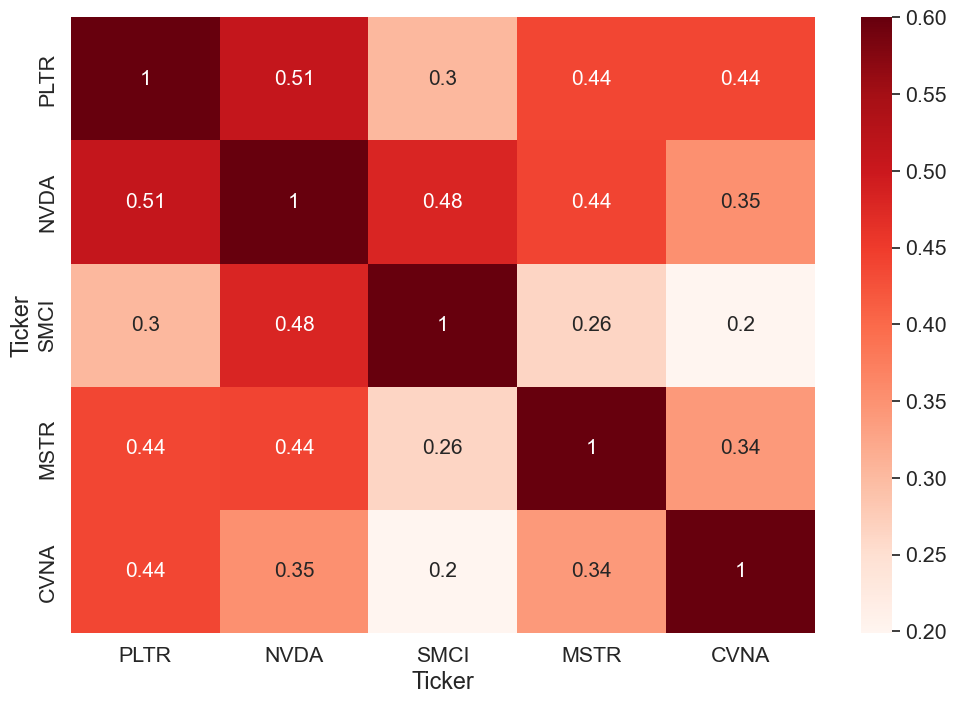

In [42]:
portfolio = ["PLTR", "NVDA", "SMCI", "MSTR", "CVNA"]
plt.figure(figsize=(12,8))
sns.set(font_scale = 1.4)
sns.heatmap(ret[portfolio].corr(),cmap = "Reds", annot = True, annot_kws = {"size":15},vmax = 0.6)
plt.show()